In [ ]:
# EDA means examining and understanding the data using statistics and visualizations before we perform the main route-efficiency analysis.

In [2]:
import pandas as pd

df_eda = pd.read_csv(
    r"D:\Nassu Project\Nassau-Candy-Shipping-Analysis\data\processed\feature_engineered_data.csv"
)

In [2]:
df_eda.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Factory,Shipping Lead Time,Route,Region Route
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,Wicked Choccy's,909,Wicked Choccy's → Texas,Wicked Choccy's → Interior
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,Wicked Choccy's,909,Wicked Choccy's → Illinois,Wicked Choccy's → Interior
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,Lot's O' Nuts,909,Lot's O' Nuts → Illinois,Lot's O' Nuts → Interior
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,Lot's O' Nuts,909,Lot's O' Nuts → Illinois,Lot's O' Nuts → Interior
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,Wicked Choccy's,912,Wicked Choccy's → Pennsylvania,Wicked Choccy's → Atlantic


In [3]:
df_eda.shape

(10194, 22)

In [4]:
df_eda.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Factory',
       'Shipping Lead Time', 'Route', 'Region Route'],
      dtype='str')

In [5]:
df_eda.describe()


,Row ID,Customer ID,Sales,Units,Gross Profit,Cost,Shipping Lead Time
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087,1320.841868
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647,262.444892
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000,904.000000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000,1271.000000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000,1274.000000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000,1638.000000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000,1642.000000


In [6]:
df_eda["Ship Mode"].value_counts()

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

In [7]:
df_eda["Region"].value_counts()

Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64

In [8]:
df_eda["Factory"].value_counts()

Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64

In [10]:
df_eda["Shipping Lead Time"].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Lead Time, dtype: float64

In [12]:
df_eda["Shipping Lead Time"].value_counts().head(10)

Shipping Lead Time
1273    1326
1274    1035
1639     896
1640     657
1275     612
1271     610
908      591
909      519
1272     456
1637     449
Name: count, dtype: int64

In [13]:
df_eda.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Country/Region        0
City                  0
State/Province        0
Postal Code           0
Division              0
Region                0
Product ID            0
Product Name          0
Sales                 0
Units                 0
Gross Profit          0
Cost                  0
Factory               0
Shipping Lead Time    0
Route                 0
Region Route          0
dtype: int64

In [15]:
print("Dulicate rows: ", df_eda.duplicated().sum())

Dulicate rows:  0


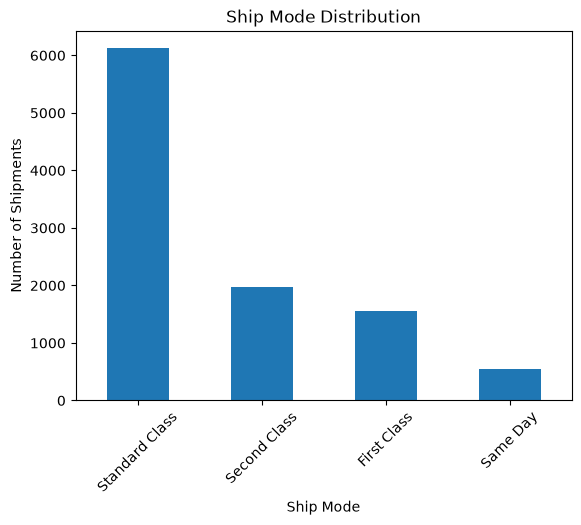

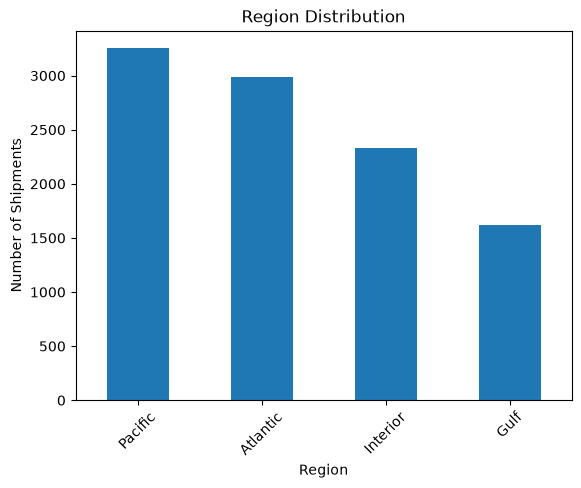

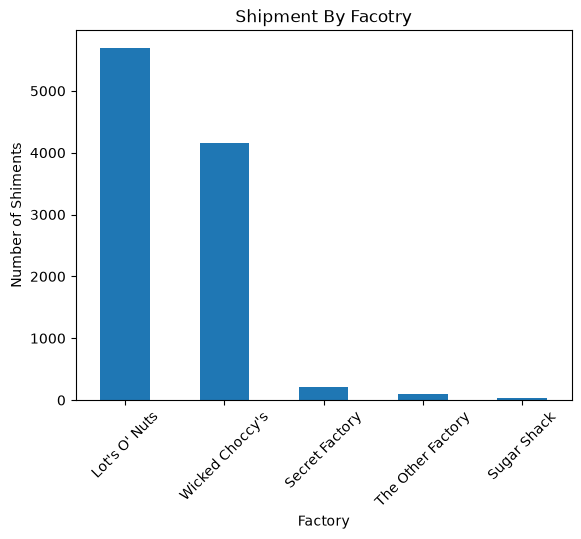

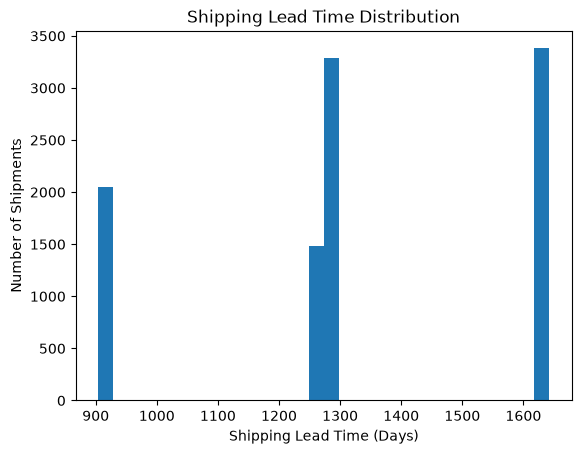

In [34]:
import matplotlib.pyplot as plt

# 1. Ship Mode Distribution
df_eda["Ship Mode"].value_counts().plot(kind="bar")
plt.title("Ship Mode Distribution")
plt.xlabel("Ship Mode")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.show()

# 2. Region Distribution
df_eda["Region"].value_counts().plot(kind="bar")
plt.title("Region Distribution")
plt.xlabel("Region")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.show()

# 3. Factory Distribution
df_eda["Factory"].value_counts().plot(kind="bar")
plt.title("Shipment By Facotry")
plt.xlabel("Factory")
plt.ylabel("Number of Shiments")
plt.xticks(rotation=45)
plt.show()

# 4. Shipping Lead Time Distribution
df_eda["Shipping Lead Time"].plot(kind="hist", bins=30)
plt.title("Shipping Lead Time Distribution")
plt.xlabel("Shipping Lead Time (Days)")
plt.ylabel("Number of Shipments")
plt.show()

In [ ]:
df_eda["State/Province"].value_counts()

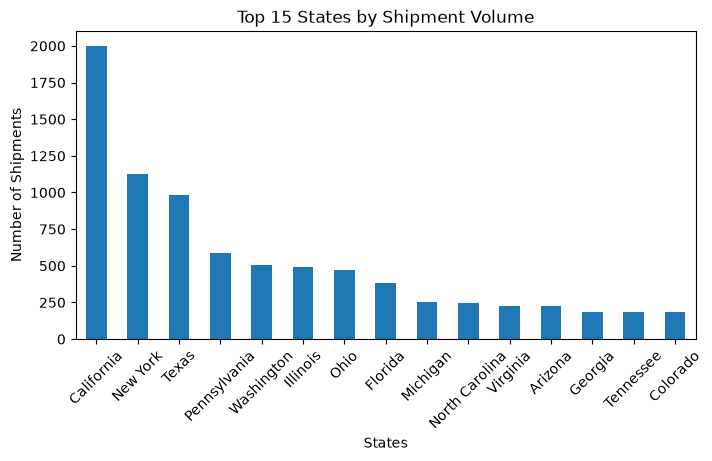

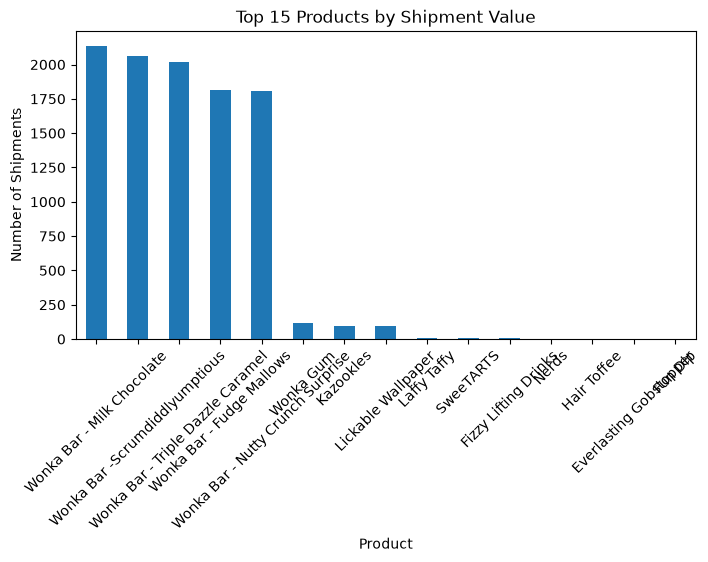

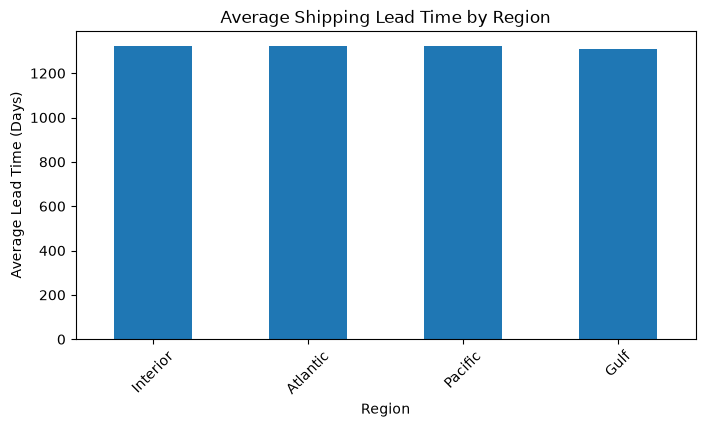

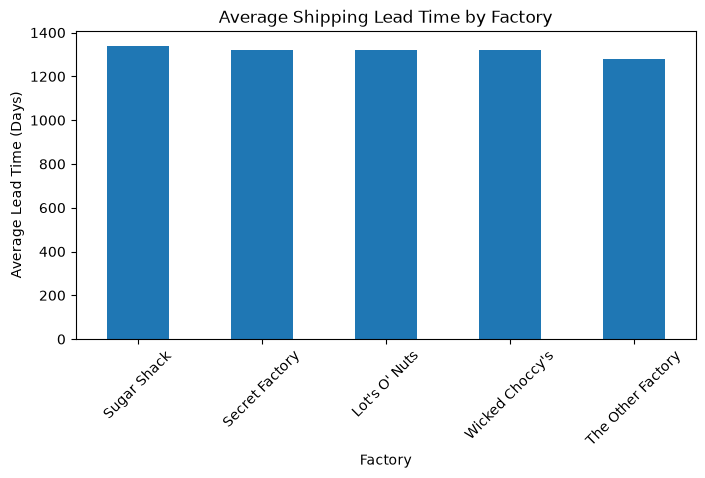

In [42]:
# State & Product Analysis

# 1. Top 15 states by shipment volume
top_states = df_eda["State/Province"].value_counts().head(15)

top_states.plot(kind="bar", figsize = (8,4))
plt.title("Top 15 States by Shipment Volume")
plt.xlabel("States")
plt.ylabel("Number of Shipments")
plt.xticks(rotation = 45)
plt.show()

# 2. Product shipment distribution
top_products = df_eda["Product Name"].value_counts().head(15)

top_products.plot(kind="bar", figsize = (8,4))
plt.title("Top 15 Products by Shipment Value")
plt.xlabel("Product")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.show()

# 3. Average Shipping Lead Time by Region
avg_region_lead = (
    df_eda.groupby("Region")["Shipping Lead Time"]
    .mean()
    .sort_values(ascending=False)
)

avg_region_lead.plot(kind="bar", figsize=(8, 4))
plt.title("Average Shipping Lead Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Lead Time (Days)")
plt.xticks(rotation=45)
plt.show()


# 4. Average Shipping Lead Time by Factory
avg_factory_lead = (
    df_eda.groupby("Factory")["Shipping Lead Time"]
    .mean()
    .sort_values(ascending=False)
)

avg_factory_lead.plot(kind="bar", figsize=(8, 4))
plt.title("Average Shipping Lead Time by Factory")
plt.xlabel("Factory")
plt.ylabel("Average Lead Time (Days)")
plt.xticks(rotation=45)
plt.show()

In [3]:
# 1. Number of shipments from each Factory to each Region
factory_region_shipments = pd.crosstab(
    df_eda["Factory"],
    df_eda["Region"]
)

print("Shipments by Factory and Region:")
display(factory_region_shipments)


# 2. Average Shipping Lead Time for each Factory → Region combination
factory_region_lead = (
    df_eda.groupby(["Factory", "Region"])["Shipping Lead Time"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Shipping Lead Time by Factory → Region:")
display(factory_region_lead)

Shipments by Factory and Region:


Region,Atlantic,Gulf,Interior,Pacific
Factory,,,,
Lot's O' Nuts,1661,897,1321,1813
Secret Factory,72,37,45,63
Sugar Shack,18,4,8,3
The Other Factory,38,19,11,32
Wicked Choccy's,1197,663,950,1342


Average Shipping Lead Time by Factory → Region:


Factory            Region  
Sugar Shack        Pacific     1516.666667
                   Atlantic    1375.388889
Secret Factory     Atlantic    1349.250000
                   Gulf        1332.540541
Wicked Choccy's    Pacific     1329.101341
Lot's O' Nuts      Atlantic    1326.825406
Wicked Choccy's    Interior    1324.551579
Lot's O' Nuts      Interior    1324.196064
Sugar Shack        Interior    1318.625000
Lot's O' Nuts      Pacific     1317.527854
Wicked Choccy's    Atlantic    1315.967419
Lot's O' Nuts      Gulf        1313.975474
Wicked Choccy's    Gulf        1309.113122
Secret Factory     Pacific     1307.730159
The Other Factory  Pacific     1307.218750
Secret Factory     Interior    1289.088889
The Other Factory  Atlantic    1282.736842
                   Gulf        1272.631579
                   Interior    1206.636364
Sugar Shack        Gulf        1091.250000
Name: Shipping Lead Time, dtype: float64